### Unforced Navier-Stokes Equations Results Replication (Section 4.3)

#### NSM Model trained for 146000 iterations, Re=4 ($\nu = 10^{-4}$)

1. PDE Residual on Test Set (recreating Figure 3(a) from the paper)

In [5]:
pde_residual_data = np.load('/mnt/home/abhagava/Neural-Spectral-Methods/log/ns.T3/re4:NSM./metric.residual.npy')

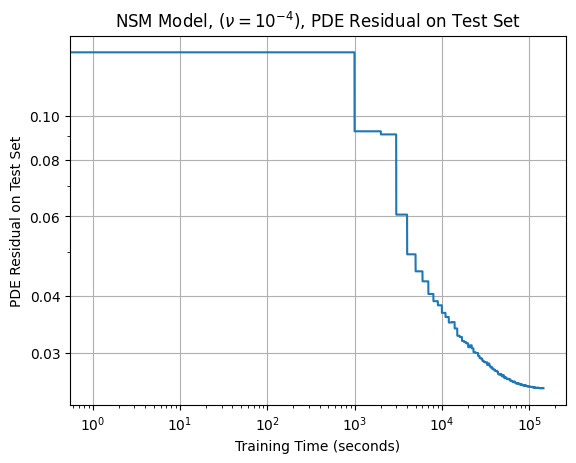

In [ ]:

plt.plot(pde_residual_data)
plt.title(r'NSM Model, ($\nu = 10^{-4}$), PDE Residual on Test Set')
plt.ylabel('PDE Residual on Test Set')
plt.xlabel('Training Time (seconds)')
plt.yscale('log')
plt.xscale('log')
yticks = [0.03, 0.04, 0.06, 0.08, 0.1]
plt.yticks(yticks, [f"{t:.2f}" for t in yticks])

plt.grid()
plt.show()

2. L2 Error on Test Set (recreating Figure 3(b) from the paper)

In [3]:
l2_error_data = np.load('/mnt/home/abhagava/Neural-Spectral-Methods/log/ns.T3/re4:NSM./metric.errr.npy')

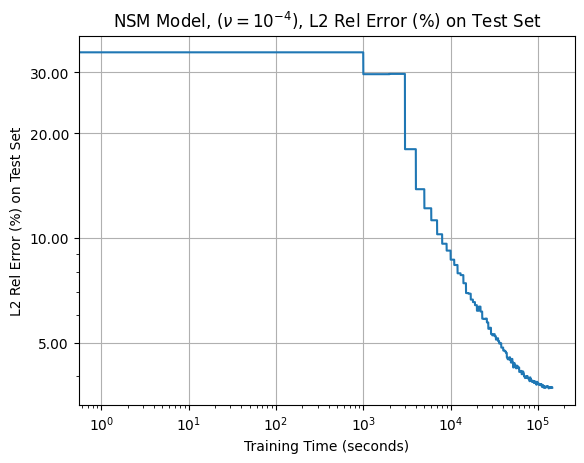

In [8]:
plt.plot(l2_error_data*100)
plt.title(r'NSM Model, ($\nu = 10^{-4}$), L2 Rel Error (%) on Test Set')
plt.ylabel('L2 Rel Error (%) on Test Set')
plt.xlabel('Training Time (seconds)')
plt.yscale('log')
plt.xscale('log')
yticks = [5, 10, 20, 30]
plt.yticks(yticks, [f"{t:.2f}" for t in yticks])

plt.grid()
plt.show()

In [31]:
print("Percentage L2 Rel Error on Test Set", l2_error_data[-1]*100)

Percentage L2 Rel Error on Test Set 3.703640401363373


3. Visualizing snapshots of predicted vorticity field

In [14]:
uhat = np.load('/mnt/home/abhagava/Neural-Spectral-Methods/log/ns.T3/re4:NSM./uhat.npy')

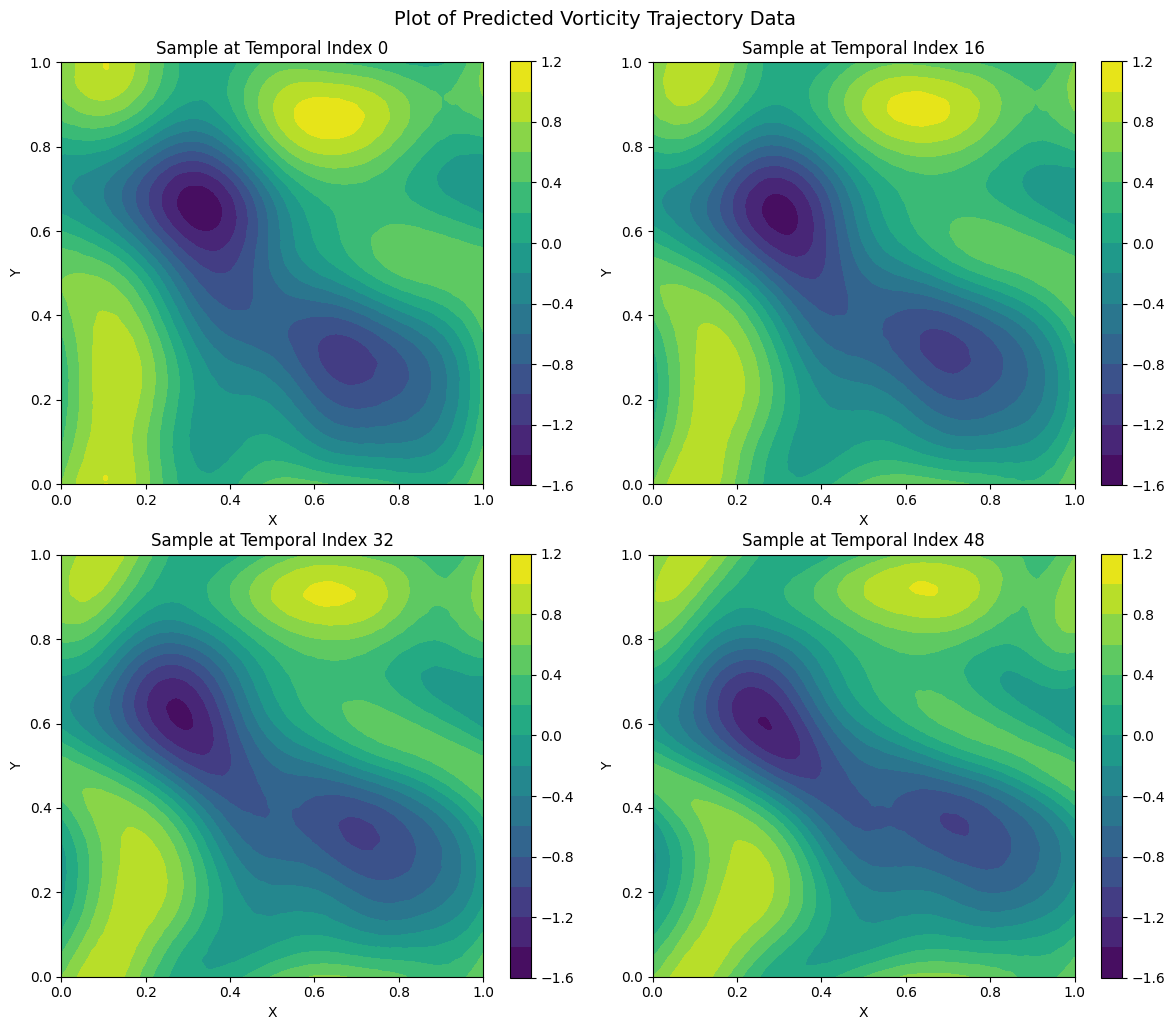

In [32]:
# plot samples from a single trajectory of data 
param1_data = uhat[0]
sample_indices = np.array([0, 16, 32, 48])
param1_data_samples = param1_data[sample_indices, :, :]


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
# Create coordinate grids for the 257x257 spatial domain
x = np.linspace(0, 1, 257) 
y = np.linspace(0, 1, 257)
X, Y = np.meshgrid(x, y)

for i in range(4):
    # Extract the 2D field
    field = param1_data_samples[i, :, :, 0]
    im = axes[i].contourf(X, Y, field, levels=15, cmap='viridis')
    # im = axes[i].imshow(field, origin='lower', cmap='viridis')
    axes[i].set_title(f'Sample at Temporal Index {sample_indices[i]}')
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('Y')
    axes[i].set_aspect('equal')
    plt.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.suptitle('Plot of Predicted Vorticity Trajectory Data', y=1.02, fontsize=14)
plt.show()


4. Temporal Resolution Frame by Frame Loss Comparison

In [ ]:
uhat_pred = np.load('/mnt/home/abhagava/Neural-Spectral-Methods/log/ns.T3/re4:NSM./uhat.npy')
uhat_true = np.load('/mnt/home/abhagava/Neural-Spectral-Methods/src/pde/navierstokes/u.Re=8000:T=3:None.npy')

NameError: name 'np' is not defined

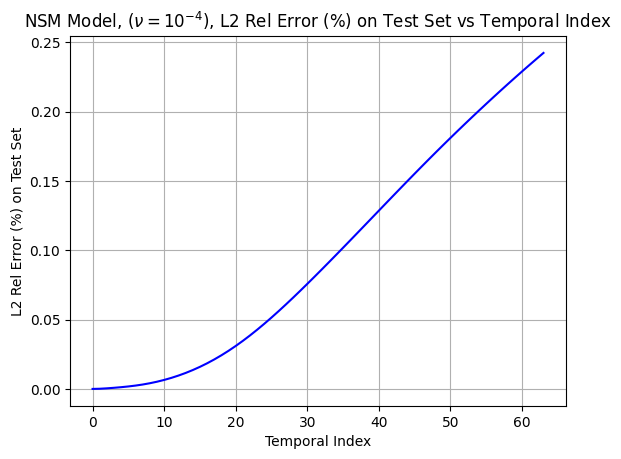

In [ ]:
# determine the difference between the predicted and true data
l2_diff = np.mean((uhat_true[0] - uhat_pred[0])**2, axis=(1, 2, 3))
plt.plot(l2_diff*100, color='blue') 
plt.title(r'NSM Model, ($\nu = 10^{-4}$), L2 Rel Error (%) on Test Set vs Temporal Index')
plt.ylabel('L2 Rel Error (%) on Test Set')
plt.xlabel('Temporal Index')
plt.grid()
plt.show()

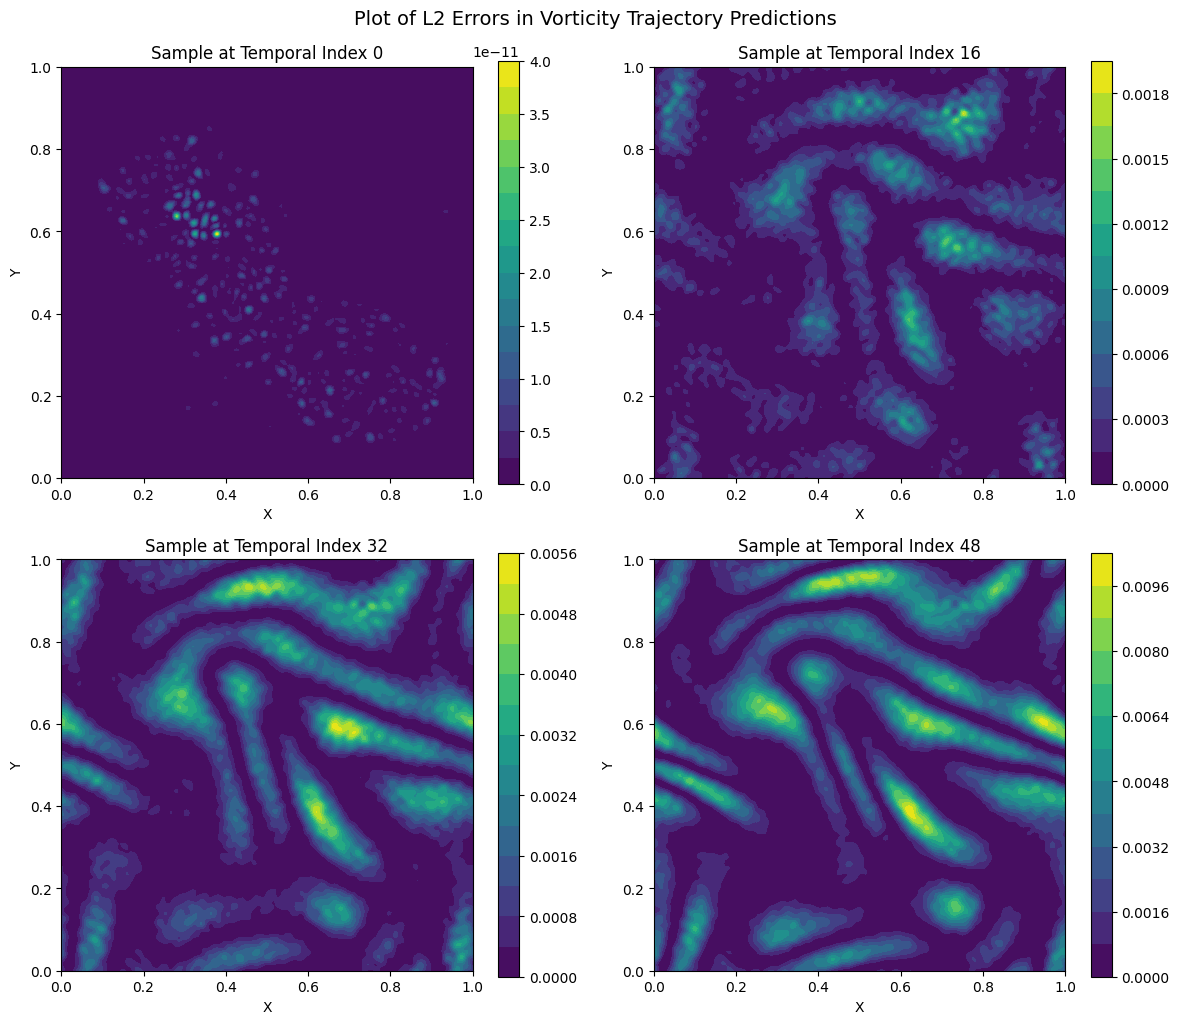

In [24]:
# plot samples from a single trajectory of data 
param1_data = (uhat_pred[0] - uhat_true[0])**2
sample_indices = np.array([0, 16, 32, 48])
param1_data_samples = param1_data[sample_indices, :, :]


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
# Create coordinate grids for the 257x257 spatial domain
x = np.linspace(0, 1, 257) 
y = np.linspace(0, 1, 257)
X, Y = np.meshgrid(x, y)

for i in range(4):
    # Extract the 2D field
    field = param1_data_samples[i, :, :, 0]
    im = axes[i].contourf(X, Y, field, levels=15, cmap='viridis')
    # im = axes[i].imshow(field, origin='lower', cmap='viridis')
    axes[i].set_title(f'Sample at Temporal Index {sample_indices[i]}')
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('Y')
    axes[i].set_aspect('equal')
    plt.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.suptitle('Plot of L2 Errors in Vorticity Trajectory Predictions', y=1.02, fontsize=14)
plt.show()
